In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import h5py
import scipy
import numpy as np
import pandas as pd
from tqdm import tqdm 

from matplotlib import pyplot as plt
import matplotlib.colors  as colors
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable

from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord

from scipy.signal import periodogram
from scipy.ndimage import median_filter
from scipy.interpolate import interp2d

import transitleastsquares as tls

# PlatoSim
import platosim.referenceFrames as rf
import platosim.plot            as pt
import platosim.utilities       as ut
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.lightcurve   import LightCurve
from platosim.validation import switchOffAllEffects
from platosim.matplotlibrc import setup_paper
setup_paper()

# Constants
day = 86400

In [73]:
# Save figure
path = '/lhome/nicholas/Nextcloud/thesis'
outputDir = os.getcwd()

## Figure for Sect. 1.5: Photometry

In [43]:
# Initialise PlatoSim (we reuse the inputfile.yaml)
outputFileName = "output_subfield"
sim = Simulation(outputFileName, outputDir=os.getcwd())

# Obs parameters
sim["ObservingParameters/NumExposures"] = 1
# sim["Platform/SolarPanelOrientation"] = 0

# Sky parameters (auto background)
sim["Sky/SkyBackground/UseConstantSkyBackground"] = 'yes'
sim["Sky/SkyBackground/BackgroundValue"]          = -1 
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield
rows, cols = 300, 300
# rows, cols = 1500, 800
sim["SubField/NumColumns"]      = 500
sim["SubField/NumRows"]         = 500
sim["SubField/ZeroPointColumn"] = cols
sim["SubField/ZeroPointRow"]    = rows

# Run simulation
simfile0 = sim.run(removeOutputFile=True)

<IPython.core.display.Javascript object>


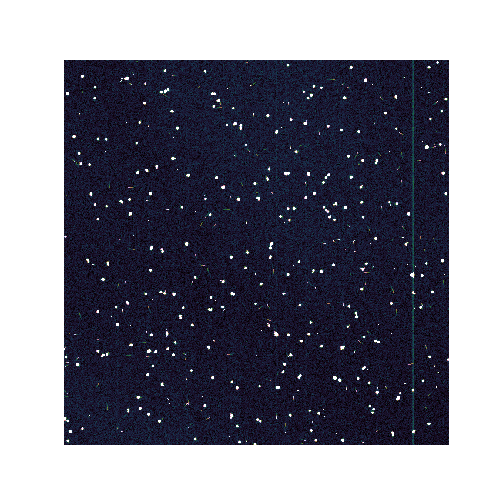

In [47]:
# Show image
f0 = SimFile(outputFileName + ".hdf5")
fig, ax = f0.showImage(0, clip=1.0, figsize=(5,5),
                       colorMap="cubehelix", colorBar=False)
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')

# Save figure
fig.savefig(f'{path}/chapters/introduction/image.png', bbox_inches='tight', dpi=300)

In [72]:
# Find target from ,catalogue of Image
# PSF photometry star ID 10
# Aperture photometry star ID 4
cat = simfile0.getStarCoordinates(0)
starID = 10
rowStar = int(cat[1][starID])
colStar = int(cat[2][starID])
fluxStar = int(cat[-1][starID])
rowStar, colStar

(114, 2)

In [70]:
# Initialise PlatoSim
outputFile = "output_imagette"
sim = Simulation(outputFile, outputDir=os.getcwd())

# Observation
sim["ObservingParameters/NumExposures"] = 1

# Sky
sim["Sky/SkyBackground/UseConstantSkyBackground"] = 'yes'
sim["Sky/SkyBackground/BackgroundValue"]          = -1 
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield
sim["SubField/NumColumns"]      = 6
sim["SubField/NumRows"]         = 6
sim["SubField/ZeroPointColumn"] = cols + colStar - 2
sim["SubField/ZeroPointRow"]    = rows + rowStar - 3

# Control HDF5
sim["ControlHDF5Content/WriteStarPositions"]     = True
sim["ControlHDF5Content/WriteDiffusedPSF"]       = True
sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

# Run simulation
simfile = sim.run(removeOutputFile=True)

<IPython.core.display.Javascript object>


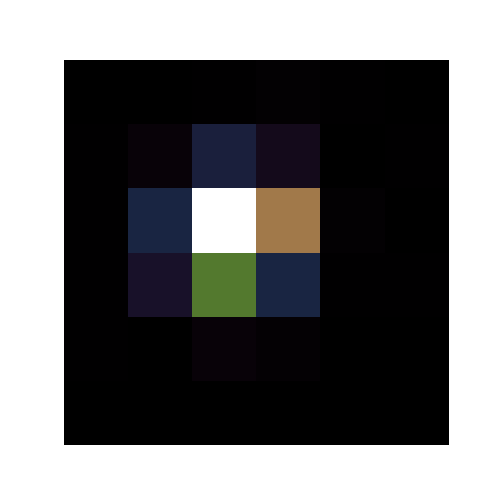

(0.0, 6.0, 0.0, 6.0)

In [71]:
# Show image
f = SimFile(outputFile + ".hdf5")
fig, ax = f.showImage(0, figsize=(5,5), clip=1.0, 
                      colorMap="cubehelix", colorBar=False,
                      tarMarkerSize=500) 

ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')

# Save figure
fig.savefig(f'{path}/chapters/introduction/imagette_aperture.png', bbox_inches='tight', dpi=300)

### Aperture photometry of contaminated target

In [ ]:
# Set up a Simulation object
sim = Simulation("output_example3", outputDir=outputDir)

# Load variable source
starID = [0, 1]
inputDir = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles"
variableSourceFile0 = inputDir + "/varsource_gdor.txt"
variableSourceFile1 = inputDir + "/varsource_algol.txt"
variableSourceFiles = [variableSourceFile0, variableSourceFile1]

# Create and set variable source file
variableSourceList  = outputDir + "/varlist_example3.txt"
sim.createVariableSourceList(starID, variableSourceFiles, variableSourceList)

# Create and set photometry file (for target star only)
starID = [0]
photometryFile = outputDir + "/photometry_example1.txt"
sim.createPhotometryFile(starID, photometryFile)

# Select subfield size and location
sim["SubField/NumColumns"]      = 8
sim["SubField/NumRows"]         = 8
sim["SubField/ZeroPointRow"]    = 3000
sim["SubField/ZeroPointColumn"] = 3000

# Define catalogue
row = np.array([4.0, 3.1]) + sim["SubField/ZeroPointRow"]
col = np.array([4.0, 2.8]) + sim["SubField/ZeroPointColumn"]
mag = np.array([12, 14])
starID = [0, 1]

# Create and set stellar catalogue file
starcatFile = outputDir + "/starcat_example3.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, starID, starcatFile)

# Save only the needed output
sim.turnOffAllOutput()
sim["ControlHDF5Content/GroupByExposure"]    = True
sim["ControlHDF5Content/WritePixelMaps"]     = True
sim["ControlHDF5Content/WriteStarPositions"] = True
sim["ControlHDF5Content/WriteCosmics"]       = True

# Run simulation
dt = 600
tdur = 30
nexp = int(tdur * 86400/dt)
sim["ObservingParameters/CycleTime"] = dt
sim["ObservingParameters/NumExposures"] = nexp

# Run simulation
simfile = sim.run(removeOutputFile=True, executionTime=True)

In [ ]:
f = SimFile("output_example3.hdf5")
df = f.getLightCurve(starID[0], fluxType='estimated', df=True)

fig, ax = plt.subplots(1, 1, figsize=(8,3))
ax.plot(df.time/86400, ut.normalize(df.flux, factor=1e3), '.', c='fuchsia', ms=5, alpha=0.2)
ax.axvline(x=14, linestyle=':', c='k')
ax.set_xlim(0, tdur)
ax.set_xlabel(r'Time $\rightarrow$')
ax.set_ylabel(r'Flux $\rightarrow$')
ax.set_xticks([])
ax.set_yticks([]);

# Save figure
fig.savefig(f'{path}/chapters/introduction/photometry_aperture.png', bbox_inches='tight', dpi=300)

### PSF photometry target

In [155]:
# Set up a Simulation object
sim = Simulation("output_psf_target", outputDir=outputDir)

# Run simulation
dt = 600
tdur = 30
nexp = int(tdur * 86400/dt)
sim["ObservingParameters/CycleTime"] = dt
sim["ObservingParameters/NumExposures"] = nexp

# Load variable source
starID = [0]
inputDir = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles"
variableSourceFile0 = inputDir + "/varsource_gdor.txt"
variableSourceFiles = [variableSourceFile0]

# Create and set variable source file
variableSourceList  = outputDir + "/varlist.txt"
sim.createVariableSourceList(starID, variableSourceFiles, variableSourceList)

# Create and set photometry file (for target star only)
starID = [0]
photometryFile = outputDir + "/photometry.txt"
sim.createPhotometryFile(starID, photometryFile)

# Change mask update
sim["Photometry/MaskUpdateInterval"] = tdur

# Select subfield size and location
sim["SubField/NumColumns"]      = 8
sim["SubField/NumRows"]         = 8
sim["SubField/ZeroPointRow"]    = 3000
sim["SubField/ZeroPointColumn"] = 3000

# Define catalogue
row = np.array([4.0, 3.1]) + sim["SubField/ZeroPointRow"]
col = np.array([4.0, 2.8]) + sim["SubField/ZeroPointColumn"]
mag = np.array([12, 14])
starID = [0, 1]

# Create and set stellar catalogue file
starcatFile = outputDir + "/starcat.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, starID, starcatFile)

# Save only the needed output
sim.turnOffAllOutput()
sim["ControlHDF5Content/GroupByExposure"]    = True
sim["ControlHDF5Content/WritePixelMaps"]     = True
sim["ControlHDF5Content/WriteStarPositions"] = True
sim["ControlHDF5Content/WriteCosmics"]       = True

# Run simulation
simfile = sim.run(removeOutputFile=True, executionTime=True)

Execution time : 0:00:39.837488 [hh:mm:ss]


In [156]:
# Set up a Simulation object
sim = Simulation("output_psf_contaminant", outputDir=outputDir)

# Run simulation
dt = 600
tdur = 30
nexp = int(tdur * 86400/dt)
sim["ObservingParameters/CycleTime"] = dt
sim["ObservingParameters/NumExposures"] = nexp

# Load variable source
starID = [1]
inputDir = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles"
variableSourceFile1 = inputDir + "/varsource_algol.txt"
variableSourceFiles = [variableSourceFile1]

# Create and set variable source file
variableSourceList  = outputDir + "/varlist.txt"
sim.createVariableSourceList(starID, variableSourceFiles, variableSourceList)

# Create and set photometry file (for target star only)
starID = [1]
photometryFile = outputDir + "/photometry.txt"
sim.createPhotometryFile(starID, photometryFile)

# Change mask update
sim["Photometry/MaskUpdateInterval"] = tdur

# Select subfield size and location
sim["SubField/NumColumns"]      = 8
sim["SubField/NumRows"]         = 8
sim["SubField/ZeroPointRow"]    = 3000
sim["SubField/ZeroPointColumn"] = 3000

# Define catalogue
row = np.array([4.0, 3.1]) + sim["SubField/ZeroPointRow"]
col = np.array([4.0, 2.8]) + sim["SubField/ZeroPointColumn"]
mag = np.array([12, 14])
starID = [0, 1]

# Create and set stellar catalogue file
starcatFile = outputDir + "/starcat.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, starID, starcatFile)

# Save only the needed output
sim.turnOffAllOutput()
sim["ControlHDF5Content/GroupByExposure"]    = True
sim["ControlHDF5Content/WritePixelMaps"]     = True
sim["ControlHDF5Content/WriteStarPositions"] = True
sim["ControlHDF5Content/WriteCosmics"]       = True

# Run simulation
simfile = sim.run(removeOutputFile=True, executionTime=True)

Execution time : 0:00:40.432721 [hh:mm:ss]


<IPython.core.display.Javascript object>


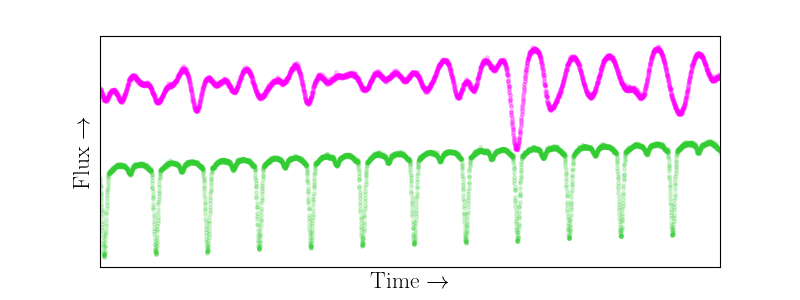

In [164]:
fig, ax = plt.subplots(1, 1, figsize=(8,3))

f = SimFile("output_psf_target.hdf5")
df = f.getLightCurve(starID[0], fluxType='estimated', df=True)
ax.plot(df.time/86400, ut.normalize(df.flux, factor=1e3), '.', c='fuchsia', ms=5, alpha=0.2)

f = SimFile("output_psf_contaminant.hdf5")
df = f.getLightCurve(starID[1], fluxType='estimated', df=True)
ax.plot(df.time/86400, ut.normalize(df.flux, factor=1e3)/4-70, '.', c='limegreen', ms=5, alpha=0.2)

ax.set_xlim(0, tdur)
ax.set_xlabel(r'Time $\rightarrow$')
ax.set_ylabel(r'Flux $\rightarrow$')
ax.set_xticks([])
ax.set_yticks([]);

# Save figure
fig.savefig(f'{path}/chapters/introduction/photometry_psf.png', bbox_inches='tight', dpi=300)